In [1]:
import os
import pdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys
sys.path.append(os.getcwd())
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
sns.set_theme(font_scale=2.1, style='whitegrid')
sns.color_palette("colorblind")
font = {'family' : 'serif',
            # 'weight' : 'bold',
            'size'   : 19}
mpl.rcParams['figure.dpi'] = 600
mpl.rc('font', **font)
mpl.rc('xtick', labelsize=19) 
plt.rcParams["font.family"] = "Nimbus Roman"
mpl.rc('ytick', labelsize=19)

In [3]:
# Load the results
perf_olmo = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "olmo2-7B_full_v2_mult_perf.csv"))
perf_mistral = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "mistral7B_full_v2_mult_perf.csv"))
perf_qwen = pd.read_csv(os.path.join(os.environ["base_dir"], "results", "qwen7B-instruct_full_v2_mult_perf.csv"))

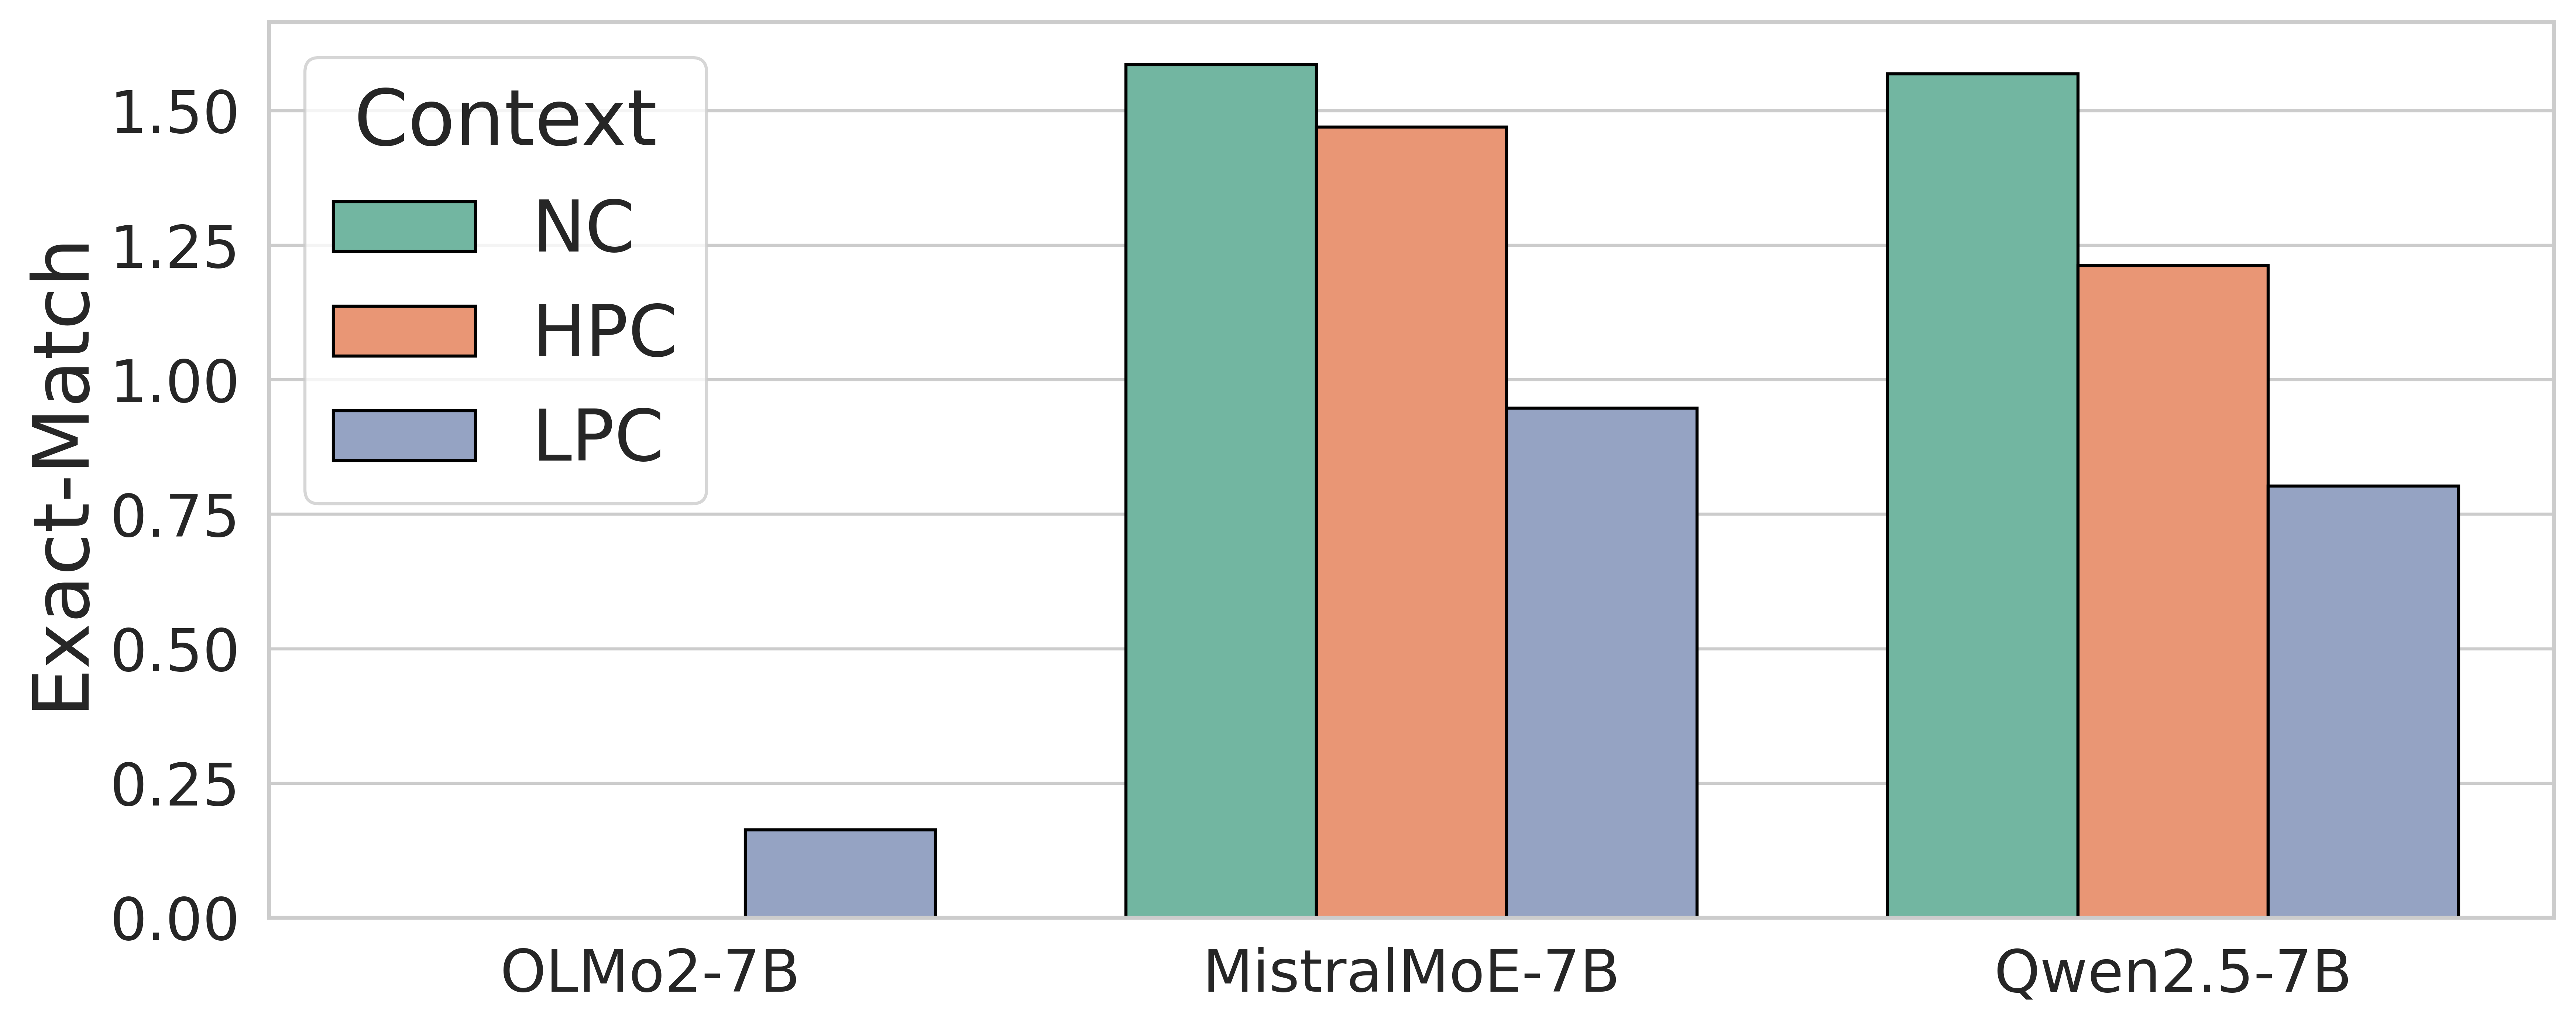

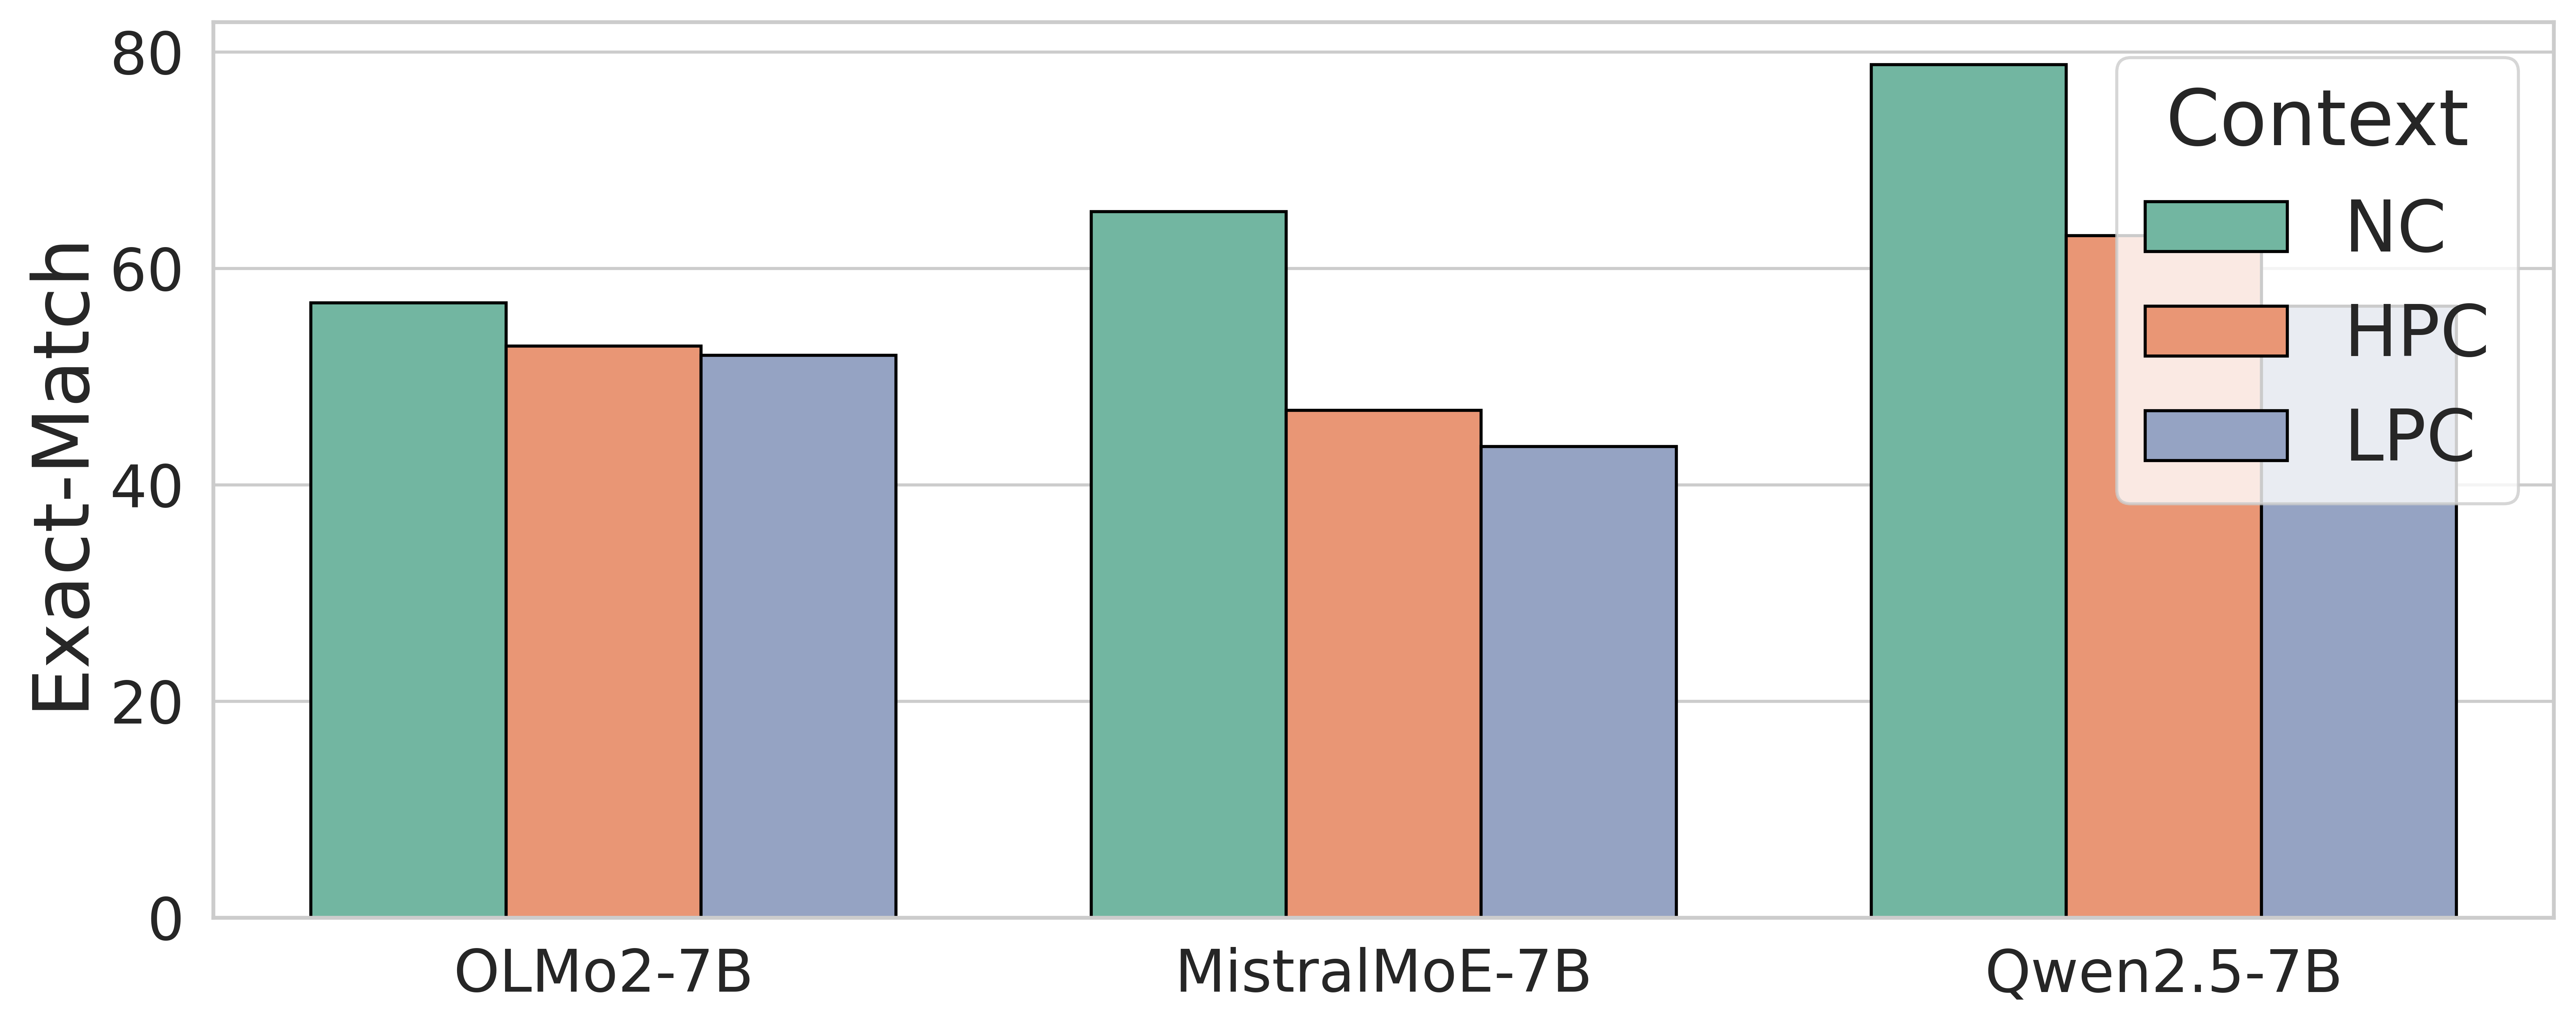

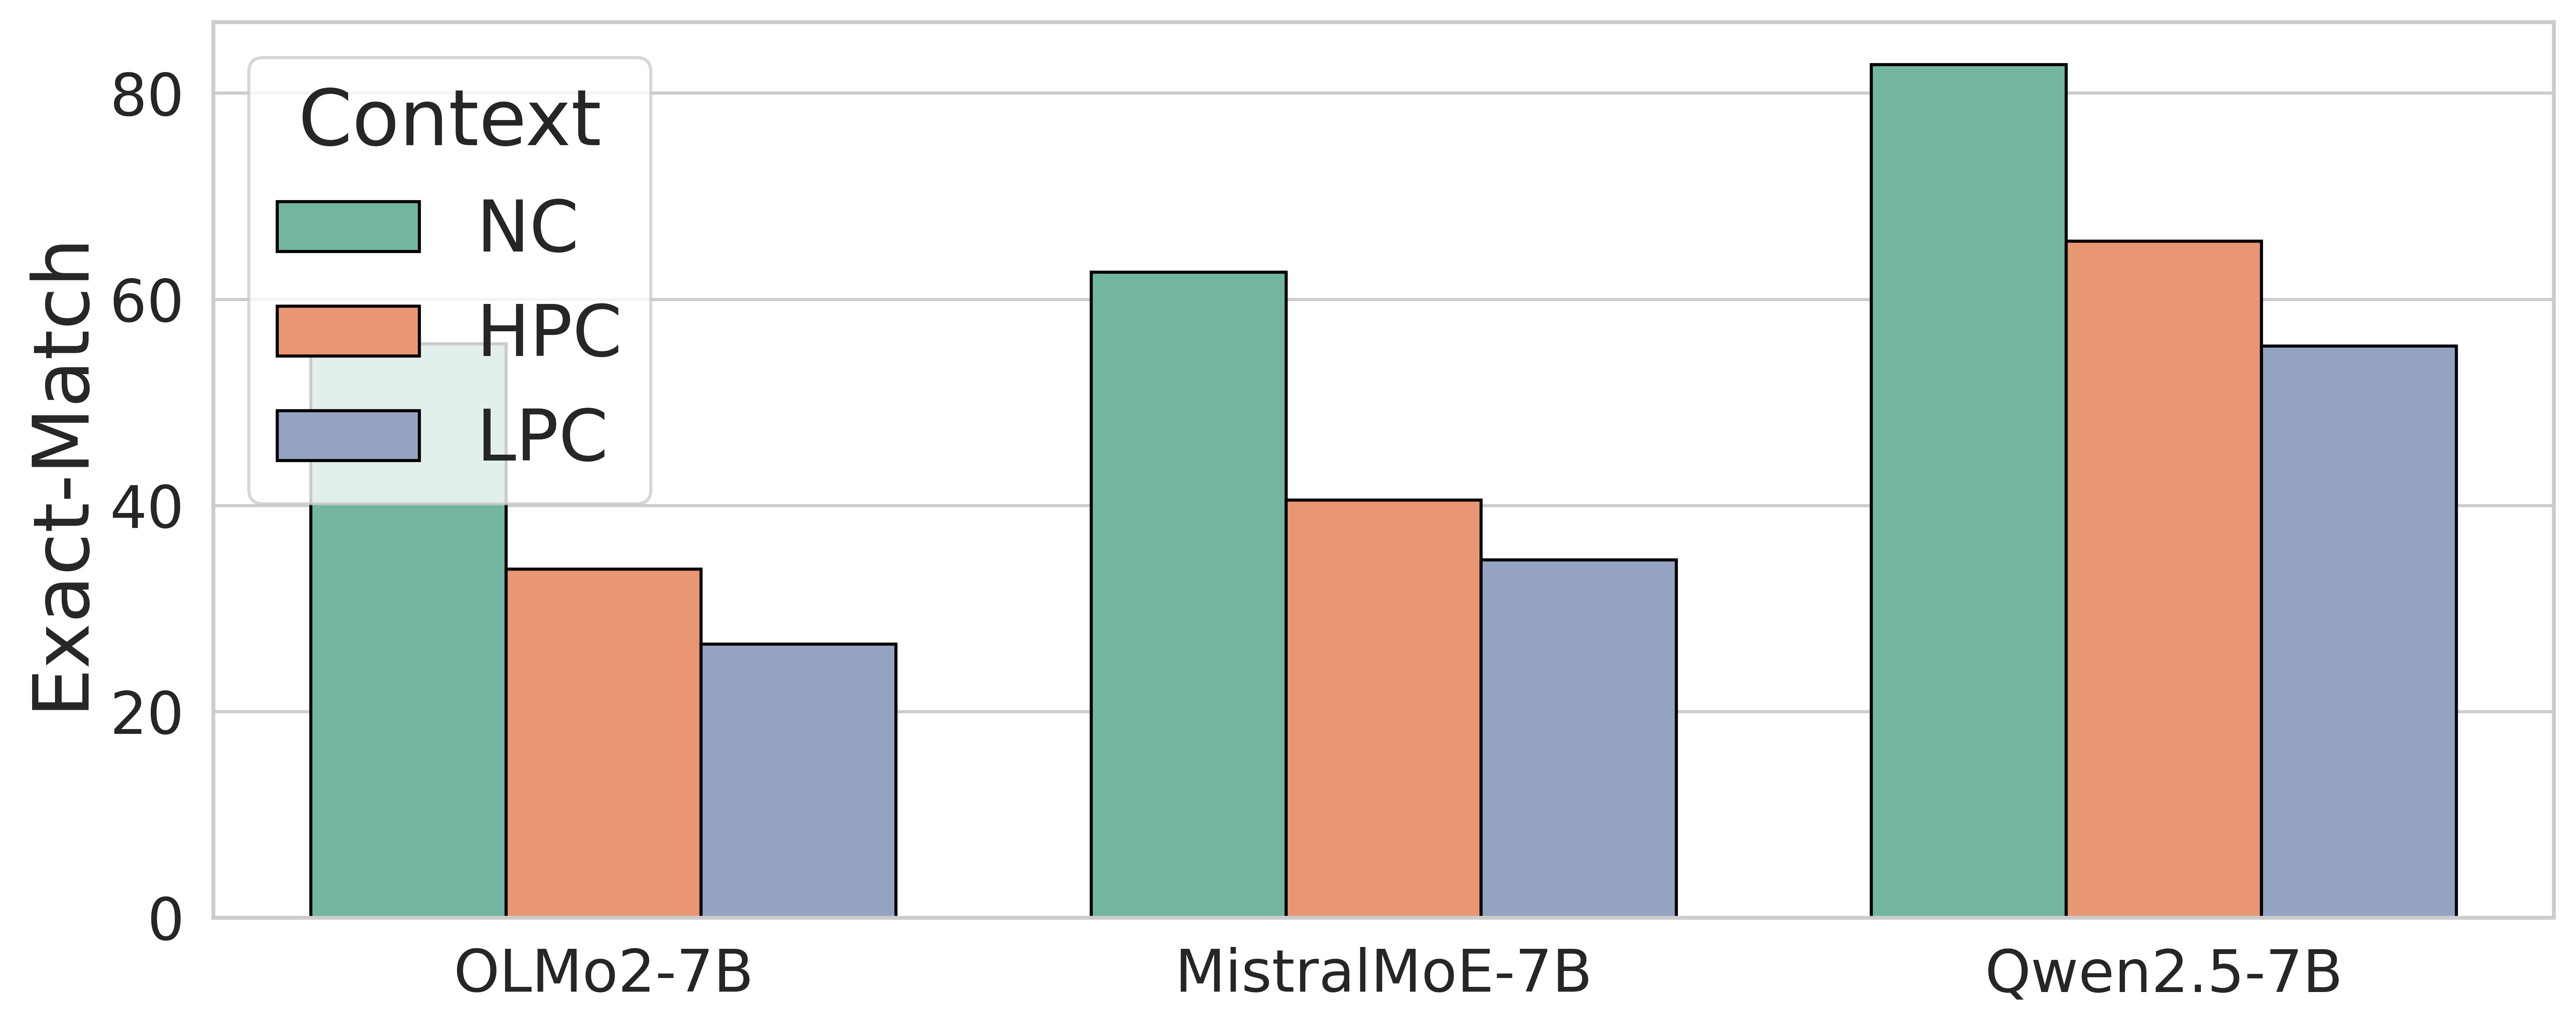

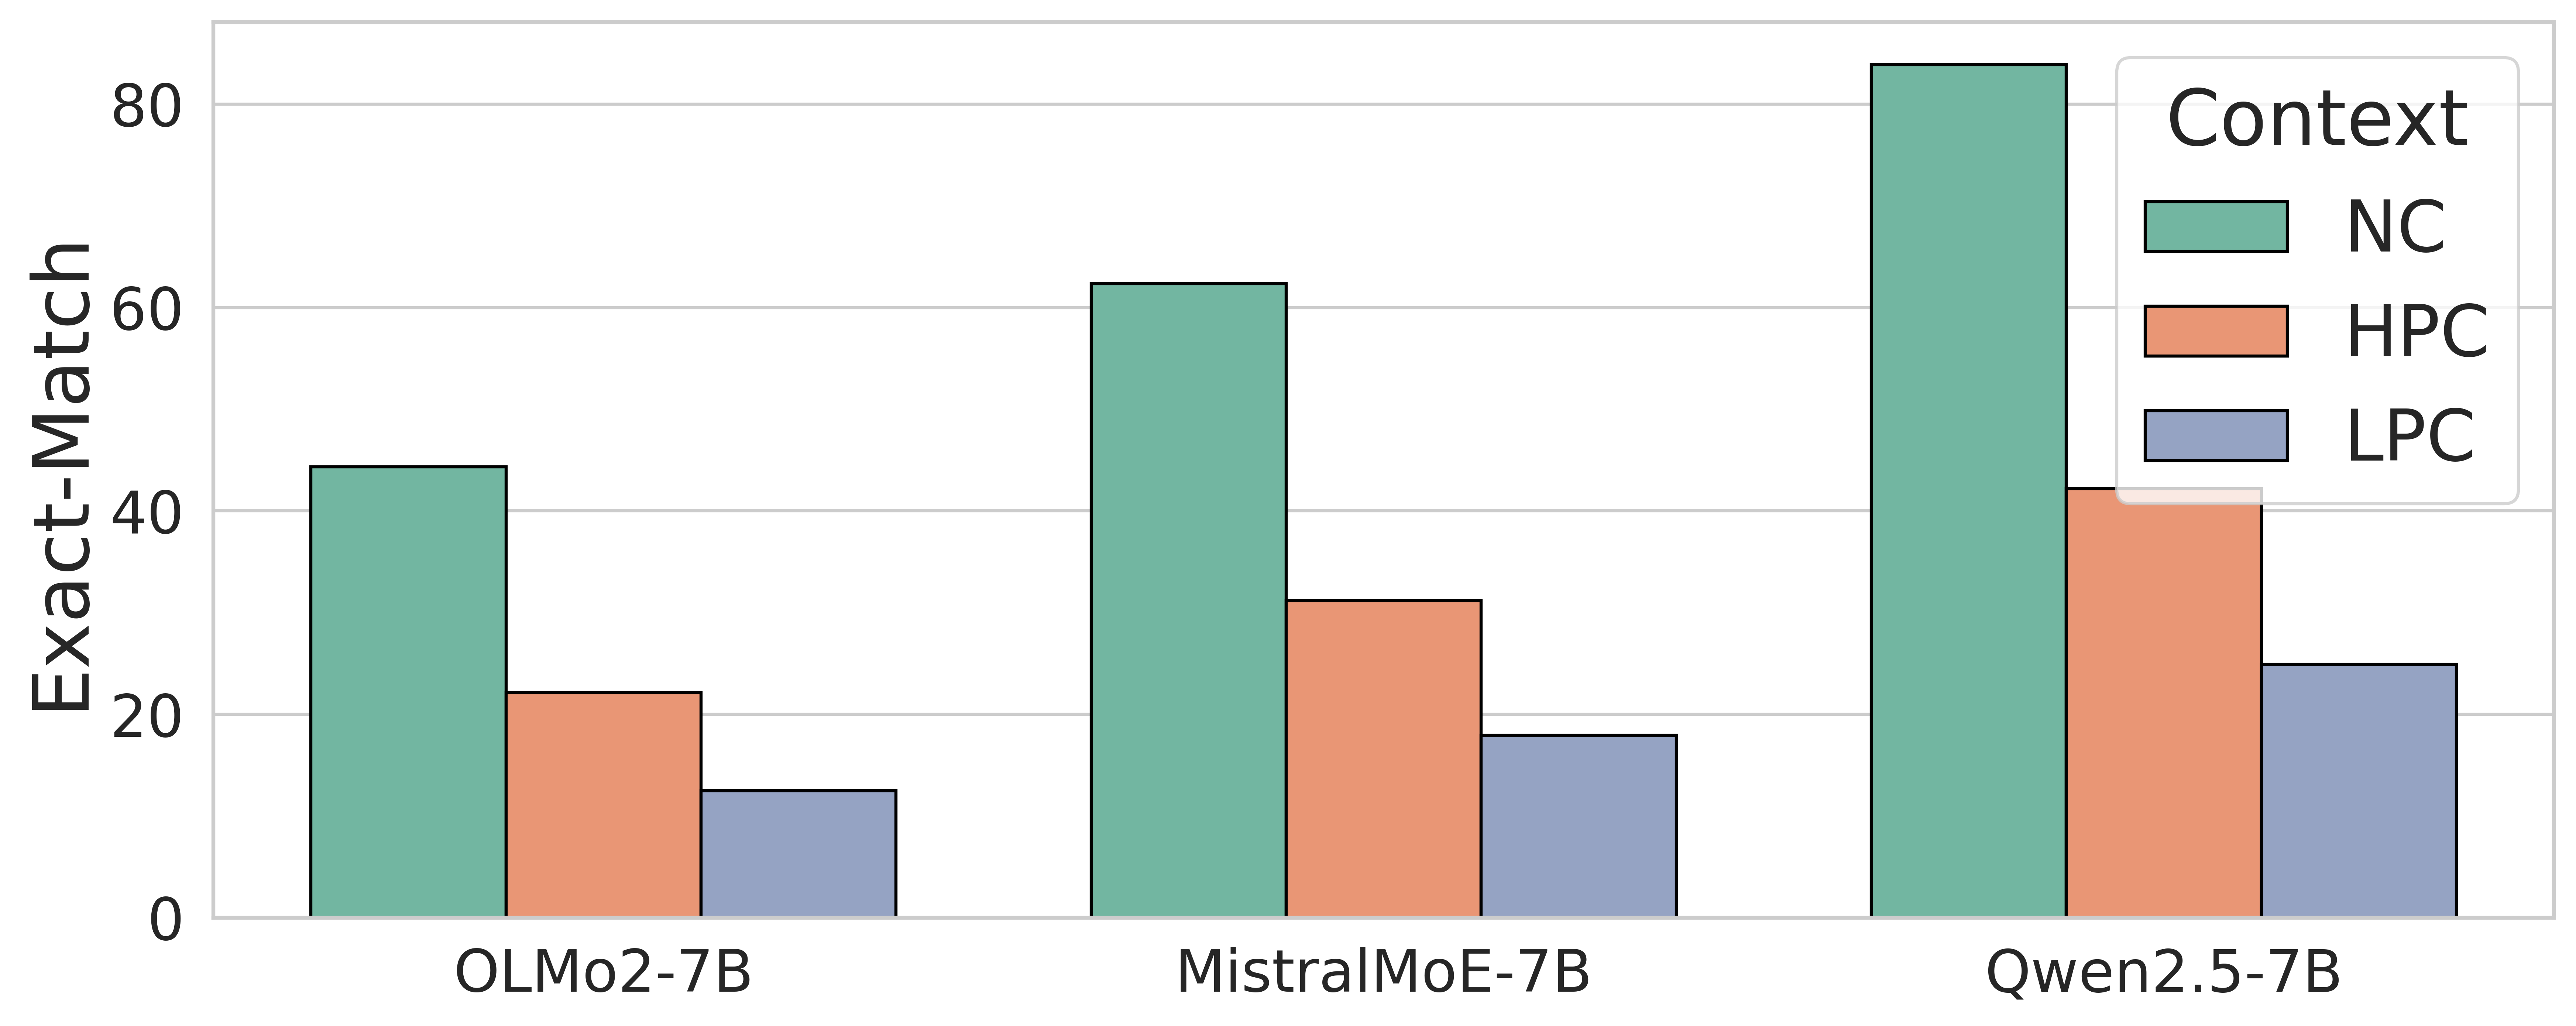

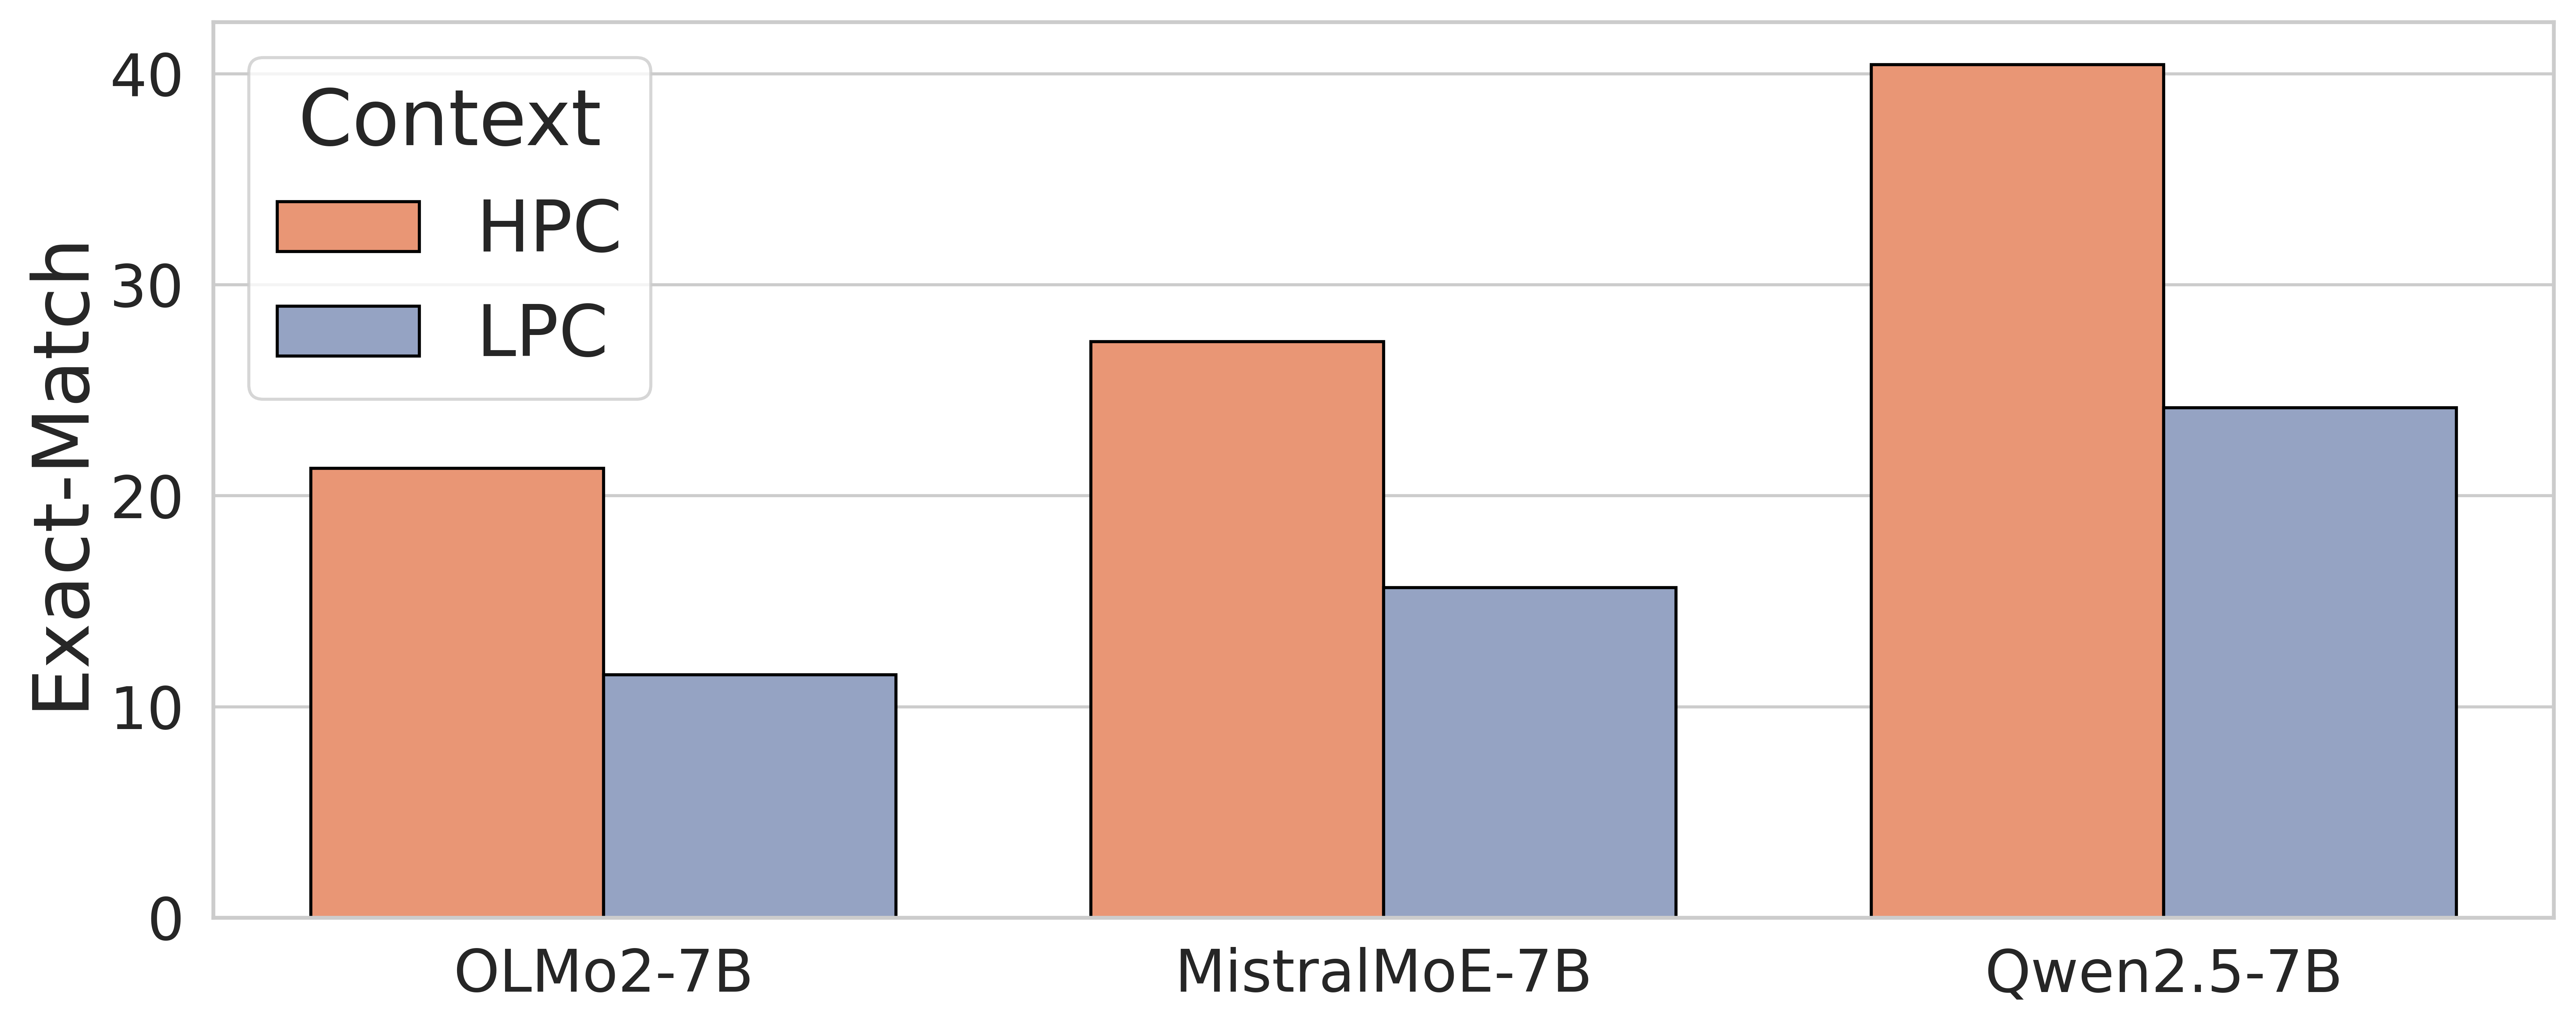

In [5]:
# ------------------------------------------------------------------
# 1)  Combine the three model‑specific DataFrames
# ------------------------------------------------------------------
dfs = []
for name, df in [('OLMo2-7B', perf_olmo), ('MistralMoE-7B', perf_mistral), ('Qwen2.5-7B', perf_qwen)]:
    tmp = df[df['metric'] == 'exact_match'].copy()   # keep only exact‑match rows
    tmp['model'] = name                              # tag the model
    dfs.append(tmp)

data = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------------
# 2)  Reshape to long format: one row per (model, task, evidence type)
# ------------------------------------------------------------------
long = data.melt(
    id_vars=['model', 'task'],
    value_vars=['NC', 'HPC', 'LPC'],                 # evidence types to plot
    var_name='evidence',
    value_name='exact_match'
)

# ------------------------------------------------------------------
# 3)  Draw one bar‑plot figure per task
# ------------------------------------------------------------------
sns.set_style('whitegrid')
set2      = sns.color_palette('Set2', 3)            # take 3 nice Set2 colors
PALETTE   = {'NC': set2[0], 'HPC': set2[1], 'LPC': set2[2]}  # consistent mapping

for t in ['KFextract', 'CK', 'PK', 'PCK', 'RAG']:
    # choose which evidence types to include
    ev_types = ['HPC', 'LPC'] if t == 'RAG' else ['NC', 'HPC', 'LPC']
    
    subset = long[(long['task'] == t) & (long['evidence'].isin(ev_types))]
    # palette = sns.color_palette('Set2', n_colors=len(ev_types))

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=subset,
        x='model',
        y='exact_match',
        hue='evidence',
        palette=PALETTE,
        width=0.75,
        edgecolor='black'
    )
    # plt.title(f'Exact-Match Accuracy by Evidence Type  |  Task: {t}')
    # plt.ylim(0, 1)                                   # remove if values are not proportions
    plt.xlabel('')
    plt.ylabel('Exact-Match')
    plt.legend(title='Context')
    plt.tight_layout()
    plt.savefig(os.path.join(os.environ['base_dir'], "results", "figures", f"{t}.pdf"), bbox_inches='tight')
    plt.show()

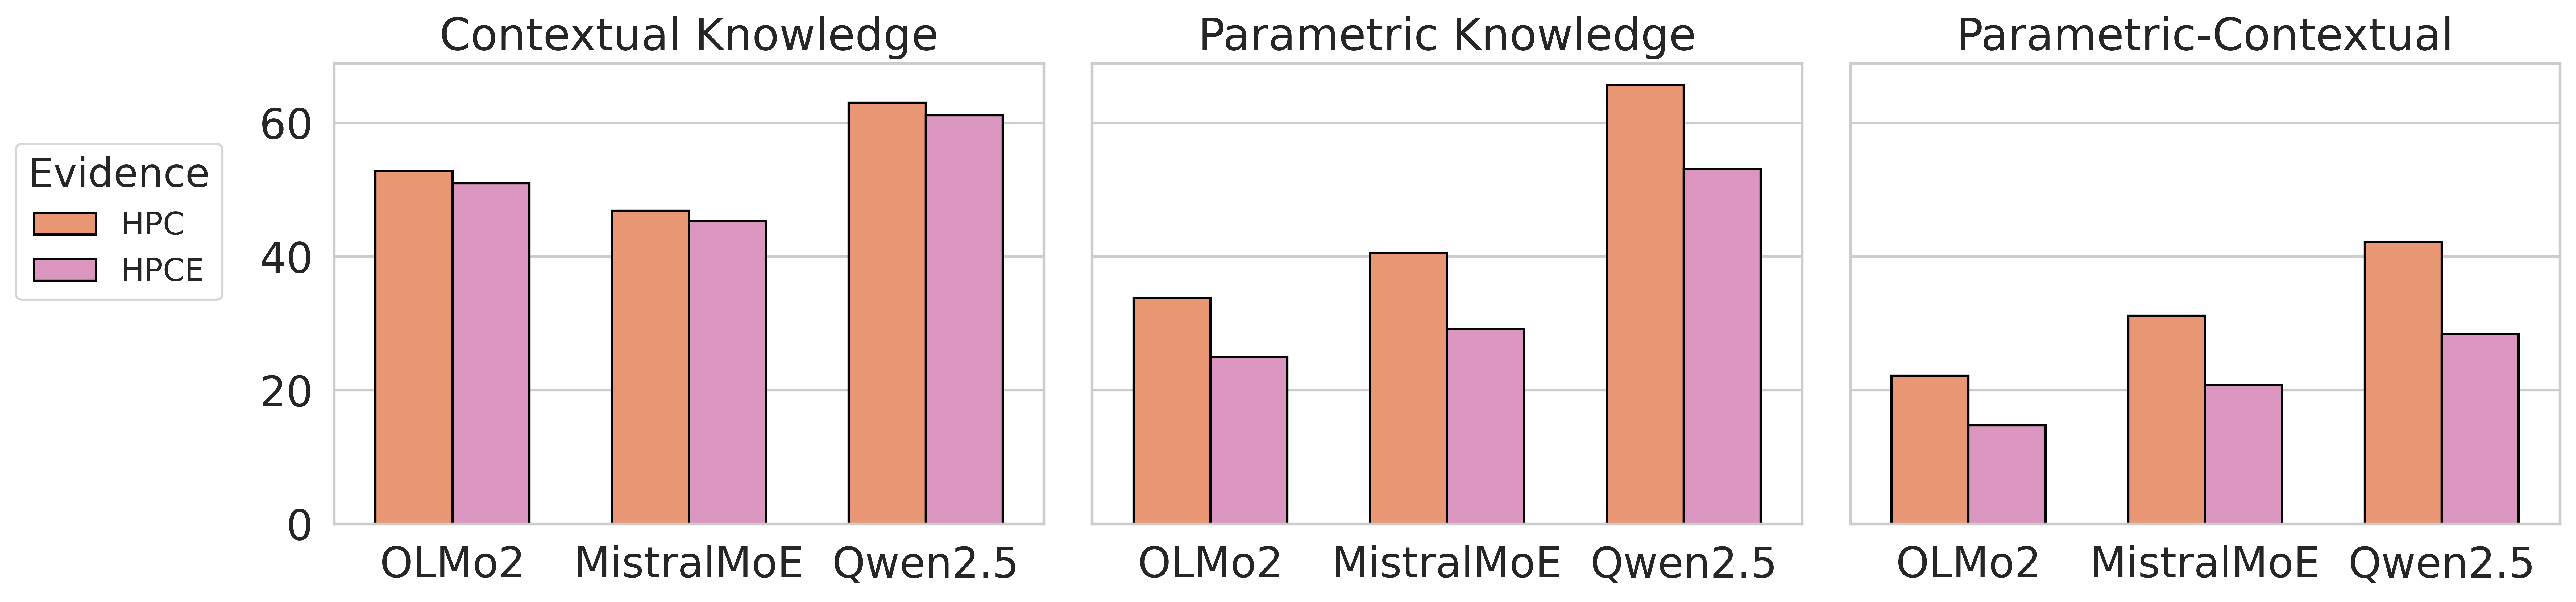

In [8]:
# HPCE Plot

# ------------------------------------------------------------------
# 0)  Combine the model‑specific DataFrames  ──(unchanged)──────────
# ------------------------------------------------------------------
dfs = []
for name, df in [('OLMo2', perf_olmo),
                 ('MistralMoE', perf_mistral),
                 ('Qwen2.5', perf_qwen)]:
    d = df[df['metric'] == 'exact_match'].copy()
    d['model'] = name
    dfs.append(d)

data = pd.concat(dfs, ignore_index=True)

# ------------------------------------------------------------------
# 1)  Long format   ──(unchanged, but add HPCE if it exists)────────
# ------------------------------------------------------------------
evidence_cols = [col for col in ['HPC', 'HPCE'] if col in data.columns]

long = data.melt(
    id_vars=['model', 'task'],
    value_vars=evidence_cols,
    var_name='evidence',
    value_name='exact_match'
)

# ------------------------------------------------------------------
# 2)  Colour map that is *fixed* across tasks  ─────────────────────
# ------------------------------------------------------------------
# palette_base = sns.color_palette('Set2', len(evidence_cols))
# PALETTE      = dict(zip(evidence_cols, palette_base))

set2      = sns.color_palette('Set2', 4)            # take 3 nice Set2 colors
PALETTE   = {'HPC': set2[1], 'HPCE': set2[3]}  # consistent mapping
HUE_ORDER    = evidence_cols                    # keep legend order stable

# ------------------------------------------------------------------
# 3)  Create ONE figure with five side‑by‑side sub‑plots  ──────────
# ------------------------------------------------------------------
tasks   = ["CK", "PK", "PCK"]
pretty_tasks   = {"CK": 'Contextual Knowledge', "PK": 'Parametric Knowledge', "PCK": 'Parametric-Contextual'}
n_tasks = len(tasks)

fig, axes = plt.subplots(
    1, n_tasks,
    figsize=(5.0 * n_tasks, 4.5),       # width ∝ number of tasks
    sharey=True                         # <- same y‑axis for all
)

for ax, t in zip(axes, tasks):
    # choose evidence types for this task
    ev_types = ['HPC', 'HPCE']
    sub = long[(long['task'] == t) & (long['evidence'].isin(ev_types))]
    
    sns.barplot(
        ax=ax,
        data=sub,
        x='model', y='exact_match',
        hue='evidence', hue_order=HUE_ORDER,
        palette=PALETTE,
        width=0.65, edgecolor='black'
    )
    
    # cosmetic tweaks per subplot
    ax.set_title(pretty_tasks[t], fontsize=20, pad=6)     # ← label "which part is KF / CK / …"
    ax.set_xlabel('')                       # no per‑panel x‑label
    ax.set_ylabel('') 
    # if t != tasks[0]:
    #     ax.set_ylabel('')                   # y‑label only on first panel
    # else:
    #     ax.set_ylabel('Exact Match')
    ax.tick_params(axis='x', rotation=0)

# ------------------------------------------------------------------
# 4)  Single shared legend & layout  ───────────────────────────────
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
leg = fig.legend(
    handles, labels, title='Evidence',
    loc='upper right', bbox_to_anchor=(0.01, 0.7),
    frameon=True,
    prop={'size': 14}
)
leg.get_title().set_fontsize(18)
for ax in axes:
    ax.get_legend().remove()               # remove per‑axes legends

fig.tight_layout(rect=[0, 0, 1, 0.92])     # leave room for the legend title

# ------------------------------------------------------------------
# 5)  Save & show  ─────────────────────────────────────────────────
# ------------------------------------------------------------------
out_path = os.path.join(os.environ['base_dir'], "results", "figures", "HPCE_all.pdf")
fig.savefig(out_path, bbox_inches='tight')
plt.show()